---
title: Coalescent conditioned on a derived variant
---

In [116]:
import phasic
from phasic import (
    Graph, StateIndexer, Property, SparseObservations, ExpStepSize, configure, clear_caches,
    GaussPrior, LogGaussPrior, BetaPrior, HalfCauchyPrior, Adam, Adamelia, dense_to_sparse,
)
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement
from functools import partial
all_pairs = partial(combinations_with_replacement, r=2)
from scipy.stats import binom
from scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns
from vscodenb import set_vscode_theme
set_vscode_theme()
sns.set_palette('tab10')
configure(
    parallel_elimination=True, 
    reward_compute_cache=False, 
    graph_cache=True,
    ) ;

In [127]:
def coalescent_with_derived(state, indexer=None, N=None, s=None):
    transitions = []

    N = int(N) # callback params are always float

    # get nr of derived and ancestral lineages
    n_anc, n_der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    if n_der + n_anc == 1: # absorbing state
        return []
    freq = int(state[indexer.derived_freq])

    assert n_anc, "No ancestral lineages"
    assert n_der <= freq < N, f"invalid state: {state}, n_der={n_der}, freq={freq}, N={N}"
    assert n_anc <= N-freq <= N, f"invalid state: {state}, n_anc={n_anc}, N-freq={N-freq}, N={N}"

    # coalescence
    for i, j in all_pairs(range(indexer.lineages.state_length)):
        pair_count = state[i] * (state[j] - int(i==j)) / (1 + int(i==j))
        if not pair_count:
            continue
        pi = indexer.lineages.i2p(i)
        pj = indexer.lineages.i2p(j)
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        if n_der > 1 and bool(pi.is_derived) == bool(pj.is_derived):
            # derived clade has not coalesced, selection, coalescence of only same-ancestry lineages
            k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=pi.is_derived)
            new[k] += 1
            new[indexer.derived_freq] = freq
            if pi.is_derived:
                # both derived
                # rate = (1+s)/(N+s*freq) * 1/(N) * 2 * pair_count # same as freq*(1+s)/(N+s*freq) * freq/(N) * 2/freq**2 * pair_count                
                # rate *= (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2) # account for anc/der constraints allowing fewer pairs
                # coef = [rate, 0, 0, 0, 0]
                coef = [1, n_der, n_anc, freq, pair_count]
            else:
                # both ancestral
                # rate = 1/(N+s*freq) * 1/(N) * 2 * pair_count # same as (N-freq)/(N+s*freq) * (N-freq)/(N) * 2/(N-freq)**2 * pair_count
                # rate *= (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2) # account for anc/der constraints allowing fewer pairs
                # coef = [0, rate, 0, 0, 0]
                coef = [2, n_der, n_anc, freq, pair_count]
            transitions.append([new, coef])
        elif n_der <= 1:
            # derived clade has coalesced, neutral coalescent
            k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=0)
            new[k] += 1
            new[indexer.derived_freq] = freq if bool(pi.is_derived) == bool(pj.is_derived) else 0
            # rate = 2/N**2 * pair_count
            # coef = [0, 0, rate, 0, 0]
            coef = [3, n_der, n_anc, freq, pair_count]
            transitions.append([new, coef])

    # frequency change
    if n_der <= freq - 1 and 0 < freq < N:
        # der birth, anc death (freq decrease backwards in time)
        new = state.copy()
        new[indexer.derived_freq] = freq - 1
        # rate = freq*(1+s)/(N+s*freq) * (N-freq)/N
        # coef = [0, 0, 0, rate, 0]
        coef = [4, n_der, n_anc, freq, 0]
        transitions.append([new, coef])
    if n_anc <= N-(freq+1) and 0 < freq < N-1:
        # anc birth, der death (freq increase backwards in time)
        new = state.copy()
        new[indexer.derived_freq] = freq + 1
        # rate = (N-freq)/(N+s*freq) * freq/N
        # coef = [0, 0, 0, 0, rate]
        coef = [5, n_der, n_anc, freq, 0]
        transitions.append([new, coef])

    return transitions


N = 100
s = 0
n_ancestral = 4
n_derived = 4

indexer = StateIndexer(
    "derived_freq",
    lineages=[
        Property('descendants', min_value=1, max_value=n_ancestral + n_derived),        
        Property('is_derived', min_value=0, max_value=1),        
        ],
)
ipv = []
freqs = np.arange(n_derived, N-n_ancestral+1, dtype=int)
rates = beta(1 + n_derived, 1 + n_ancestral).pdf(freqs / N)
rates /= (rates.sum() + 1e-12)
for freq, rate in zip(freqs, rates):
    state = [0] * indexer.state_length
    state[indexer.lineages.p2i(descendants=1, is_derived=0)] = n_ancestral
    state[indexer.lineages.p2i(descendants=1, is_derived=1)] = n_derived
    state[indexer.derived_freq] = freq
    if rate:
        ipv.append([state, rate])
# ax = plt.subplot(111)
# ax.vlines(freqs, ymin=0, ymax=rates, zorder=0)
# ax.scatter(freqs, rates)
# ax.set_title('Beta IPV')

graph = Graph(coalescent_with_derived, ipv=ipv, indexer=indexer, N=N, s=s, theta_dim=2)

derived_coal = '(1+sel_coef)/(N+sel_coef*freq) * 1/(N) * 2 * pair_count * (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2)'
ancestral_coal = '1/(N+sel_coef*freq) * 1/(N) * 2 * pair_count * (n_der+n_anc)*(n_der+n_anc-1)/2 / (n_der*(n_der-1)/2 + n_anc*(n_anc-1)/2)'
neutral_coal = '2/N**2 * pair_count'
freq_increase = 'freq*(1+sel_coef)/(N+sel_coef*freq) * (N-freq)/N'
freq_decrease = '(N-freq)/(N+sel_coef*freq) * freq/N'
weight_formula = f"""
select(c0==1, {derived_coal}, 0.0) +
select(c0==2, {ancestral_coal}, 0.0) +
select(c0==3, {neutral_coal}, 0.0) +
select(c0==4, {freq_increase}, 0.0) +
select(c0==5, {freq_decrease}, 0.0)
"""
for i, var in enumerate(['flag', 'n_der', 'n_anc', 'freq', 'pair_count']):
    if var == 'flag': continue
    weight_formula = weight_formula.replace(var, f'c{i}')
for i, var in enumerate(['N', 'sel_coef']):
    weight_formula = weight_formula.replace(var, f't{i}')

graph.weight_formula = weight_formula
true_theta = [N, s]
graph.update_weights(true_theta)
graph.expectation() * 2 / N

RuntimeError: Coefficient length mismatch: edge has 5 coefficients but theta has 2 parameters. In non-callback mode, they must match exactly. To use extra coefficients, call update_weights(theta, callback) with a custom callback function.

In [124]:

def label(vertex):
    state = vertex.state()
    anc, der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            der += state[i]
        else:
            anc += state[i]
    return f'{der} / {anc+der}, f:{state[indexer.derived_freq]}'

def subgr(state):
    s = state.tolist()
    del s[indexer.derived_freq]
    return s

def node_label(vertex):
    n_anc, n_der = 0, 0
    state = vertex.state()
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    return f'a:{n_anc}, d:{n_der}, f:{state[indexer.derived_freq]}'

graph.plot(ranksep=5, nodesep=0.5,
    subgraphfun=lambda state: str(state[:-1]), label_fmt=node_label,
   color_by = graph.expected_sojourn_time(), 
    # size=(15, 15), max_nodes=500,
    )

Graph has too many nodes (2413). Please set max_nodes to a higher value.


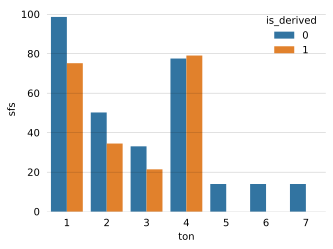

In [126]:
records = []
for ton in range(1, indexer.lineages.property_dict['descendants'].max_value):
    for is_derived in [0, 1]:
        i = indexer.lineages.props_to_index(descendants=ton, is_derived=is_derived)
        records.append([ton, is_derived, graph.expectation(rewards=graph.states().T[:-1][i]) * 2 / N])
df = pd.DataFrame().from_records(records, columns=['ton', 'is_derived', 'sfs'])
sns.barplot(data=df, x='ton', y='sfs', hue='is_derived') ;

<Axes: >

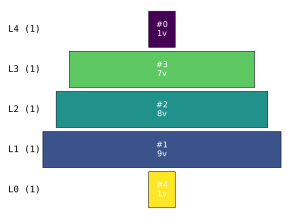

In [24]:
graph.plot_scc_decomp()

In [100]:
graph.states()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 3, 0, 0, 0, 3],
       [1, 0, 0, 0, 3, 0, 0, 0, 4],
       [1, 0, 0, 0, 3, 0, 0, 0, 5],
       [1, 0, 0, 0, 3, 0, 0, 0, 6],
       [1, 0, 0, 0, 3, 0, 0, 0, 7],
       [1, 0, 0, 0, 3, 0, 0, 0, 8],
       [1, 0, 0, 0, 3, 0, 0, 0, 9],
       [1, 0, 0, 0, 1, 1, 0, 0, 3],
       [1, 0, 0, 0, 1, 1, 0, 0, 4],
       [1, 0, 0, 0, 1, 1, 0, 0, 5],
       [1, 0, 0, 0, 1, 1, 0, 0, 6],
       [1, 0, 0, 0, 1, 1, 0, 0, 7],
       [1, 0, 0, 0, 1, 1, 0, 0, 8],
       [1, 0, 0, 0, 1, 1, 0, 0, 9],
       [1, 0, 0, 0, 0, 0, 1, 0, 3],
       [1, 0, 0, 0, 1, 1, 0, 0, 2],
       [1, 0, 0, 0, 0, 0, 1, 0, 4],
       [1, 0, 0, 0, 0, 0, 1, 0, 5],
       [1, 0, 0, 0, 0, 0, 1, 0, 6],
       [1, 0, 0, 0, 0, 0, 1, 0, 7],
       [1, 0, 0, 0, 0, 0, 1, 0, 8],
       [1, 0, 0, 0, 0, 0, 1, 0, 9],
       [0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 1, 0, 2],
       [1, 0, 0, 0, 0, 0, 1, 0, 1]], dtype=int32)

In [107]:
for i in range(indexer.state_length):
    print(indexer.i2p(i))

IndexResult(lineages=LineagesProps(descendants=1, is_derived=0), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=2, is_derived=0), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=3, is_derived=0), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=4, is_derived=0), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=1, is_derived=1), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=2, is_derived=1), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=3, is_derived=1), derived_freq=None)
IndexResult(lineages=LineagesProps(descendants=4, is_derived=1), derived_freq=None)
IndexResult(lineages=None, derived_freq=True)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = np.genfromtxt('eye_.txt',delimiter=',')

x=data[:,0]
y=data[:,1]
z=data[:,2]

## Equivalently, we could do that all in one line with:
# x,y,z = np.genfromtxt('eye_.txt', delimiter=',', usecols=(0,1,2))

x=np.unique(x)
y=np.unique(y)
X,Y = np.meshgrid(x,y)

Z=z.reshape(len(y),len(x))

plt.pcolormesh(X,Y,Z)

plt.show()

array([[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0],
       [0, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0]], dtype=int32)

In [ ]:

n = 1000
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)

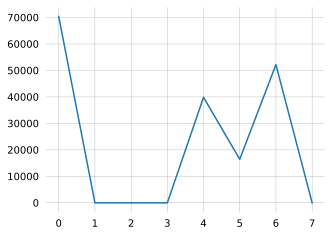

In [86]:
plt.plot(np.array([graph.sample(n, rewards=r) for r in rewards]).sum(axis=1))

In [52]:
graph = Graph(coalescent_with_derived, ipv=ipv, indexer=indexer, N=N, s=s, theta_dim=2)
graph.weight_formula = weight_formula
graph.update_weights(true_theta)

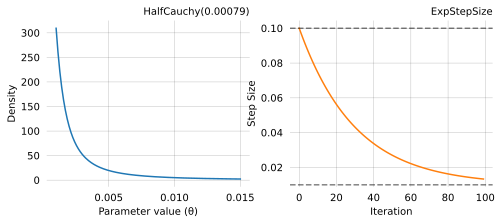

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
hc_prior = HalfCauchyPrior(ci=0.01)

step_schedule = ExpStepSize(first_step=0.1, last_step=0.01, tau=30.0)

hc_prior.plot(ax=ax[0]) ;
step_schedule.plot(100, ax=ax[1]);

In [71]:
%%monitor
svgd = graph.svgd(observed_data=dense_to_sparse(observed_data), 
                  rewards=rewards,
                  fixed=[(0, N)], # the last three are just to fix the padding of empty slots to make theta same length of coefficients
                  prior=[None, hc_prior],
                  n_iterations=20,     
                  n_particles=20,
                  learning_rate=step_schedule,
                #   optimizer = Adam(
                #     learning_rate=0.1,  # Base learning rate, scaled per-parameter by Adam (alpha)
                #     beta1=0.9,            # Decay rate for first moment (momentum). Higher = more smoothing
                #     beta2=0.999,          # Decay rate for second moment. Higher = longer memory of gradient magnitudes
                #     epsilon=1e-8          # Small constant to prevent division by zero
                #     )
                 )
svgd.summary()

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          Yes            10         NA         NA         NA           NA          
1          No             0.0006356  0.0009817  0.001061   0.0001778    0.001452    

Particles: 20, Iterations: 20
Zero-inflated likelihood: 1: n_zero=1, 2: n_zero=1, 3: n_zero=1, 7: n_zero=1


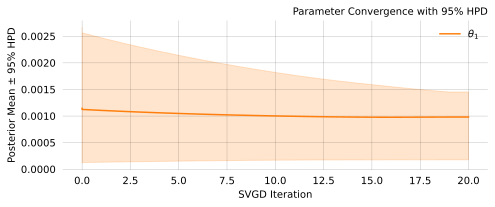

In [72]:
svgd.plot_ci()

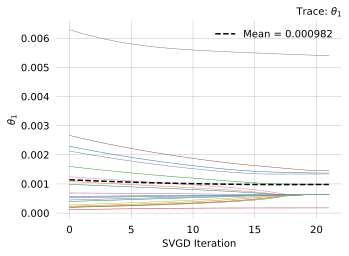

In [73]:
svgd.plot_trace()

In [75]:
svgd.animate_pairwise()

In [77]:
svgd.animate(param_idx=1)